# 03 — Modelagem, Comparação de Algoritmos e Registro MLflow

Treina 8 modelos via `comparar_modelos()`, salva cada `best_estimator_` como `.pkl` em `models/` e registra métricas/artefatos no MLflow.


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

import sys
sys.path.insert(0, '..')
from utils.metrics import avaliar_modelo, comparar_modelos
from utils.neural_net import  ChurnNetWrapper

In [2]:
df_churn = pd.read_csv("../data/Telco_customer_churn.csv")
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [3]:
df_churn = df_churn.drop(columns=['Count','CustomerID','Churn Reason'])

df_churn.head()

,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
2,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372
3,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
4,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340


In [4]:
# 1. Combo de maior risco
df_churn['high_risk_profile'] = (
    (df_churn['Internet Service'] == 'Fiber optic') & 
    (df_churn['Contract'] == 'Month-to-month')
).astype(int)

# 2. Perfil vulnerável
df_churn['isolated_senior'] = (
    (df_churn['Senior Citizen'] == 'Yes') & 
    (df_churn['Partner'] == 'No') & 
    (df_churn['Dependents'] == 'No')
).astype(int)

# 3. Engajamento com serviços
servicos = ['Online Security','Online Backup','Device Protection',
            'Tech Support','Streaming TV','Streaming Movies']
df_churn['internet_services_count'] = sum((df_churn[c] == 'Yes').astype(int) for c in servicos)

# 4. Custo relativo ao tempo de permanência
df_churn['cost_per_month'] = df_churn['Monthly Charges'] / (df_churn['Tenure Months'] + 1)

In [5]:
df_churn["Total Charges"] = pd.to_numeric(df_churn["Total Charges"], errors='coerce')

In [6]:
df_churn['Total Charges'] = df_churn['Total Charges'].fillna(df_churn['Total Charges'].median())

## 6. Divisão Treino/Teste e Definição dos Pipelines

O encoding das variáveis categóricas e a normalização são feitos **dentro dos Pipelines** (via `OneHotEncoder` e `StandardScaler` no `ColumnTransformer`), eliminando o data leakage que ocorre ao fazer `pd.get_dummies()` antes do split.

In [7]:
from sklearn.model_selection import train_test_split

# ── Remover colunas de data leakage e geográficas desnecessárias ──────────────
colunas_vazar       = ['Churn Score', 'CLTV', 'Churn Label']
colunas_geograficas = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
COL_TARGET          = 'Churn Value'

df_churn = df_churn.drop(
    columns=[c for c in colunas_vazar + colunas_geograficas if c in df_churn.columns]
)
print(f"Shape após remoção de leakage e colunas geográficas: {df_churn.shape}")
print(f"States únicos mantidos: {df_churn['State'].nunique()}")

# ── Separar features e target ────────────────────────────────────────────────
X_raw = df_churn.drop(columns=[COL_TARGET])
y     = df_churn[COL_TARGET]

# ── Identificar colunas por tipo (para os ColumnTransformers) ────────────────
num_cols = X_raw.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nFeatures numéricas ({len(num_cols)}): {num_cols}")
print(f"Features categóricas ({len(cat_cols)}): {cat_cols}")

# ── Split treino / teste sobre dados brutos (encoding via Pipeline) ──────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTreino: {X_train_raw.shape} | Teste: {X_test_raw.shape}")
print(f"Distribuição do target (treino): {y_train.value_counts().to_dict()}")

Shape após remoção de leakage e colunas geográficas: (7043, 25)
States únicos mantidos: 1

Features numéricas (7): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'high_risk_profile', 'isolated_senior', 'internet_services_count', 'cost_per_month']
Features categóricas (17): ['State', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Treino: (5634, 24) | Teste: (1409, 24)
Distribuição do target (treino): {0: 4139, 1: 1495}


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# DEFINIÇÃO DOS PREPROCESSORS — base para todos os Pipelines
# ══════════════════════════════════════════════════════════════════════════════

# Bloco numérico sem normalização (tree-based: RF, GB, XGB, LightGBM)
num_passthrough = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# Bloco numérico com StandardScaler (modelos sensíveis à escala: LR, KNN, SVM, NN)
num_scaled = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Bloco categórico: imputer + OneHotEncoder (igual para todos os modelos)
# handle_unknown='ignore' → categorias novas no teste não causam erro
cat_pipe = SKPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ColumnTransformer para tree-based (sem escala numérica)
preprocessor_tree = ColumnTransformer([
    ('num', num_passthrough, num_cols),
    ('cat', cat_pipe,        cat_cols),
], remainder='drop')

# ColumnTransformer para modelos sensíveis à escala
preprocessor_scaled = ColumnTransformer([
    ('num', num_scaled, num_cols),
    ('cat', cat_pipe,   cat_cols),
], remainder='drop')

print("Preprocessors definidos:")
print("  preprocessor_tree   → SimpleImputer (sem scaler) + OneHotEncoder")
print("  preprocessor_scaled → SimpleImputer + StandardScaler + OneHotEncoder")

Preprocessors definidos:
  preprocessor_tree   → SimpleImputer (sem scaler) + OneHotEncoder
  preprocessor_scaled → SimpleImputer + StandardScaler + OneHotEncoder


## 7. Modelagem — Random Forest

Modelo baseline com **RandomForestClassifier** para predição de churn.

- Split estratificado: 80% treino / 20% teste
- Avaliação: Classification Report, Matriz de Confusão e ROC-AUC
- Feature importance para identificar as variáveis mais relevantes

=== Relatório de Classificação — Random Forest Baseline ===
              precision    recall  f1-score   support

   Não Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC: 0.8366


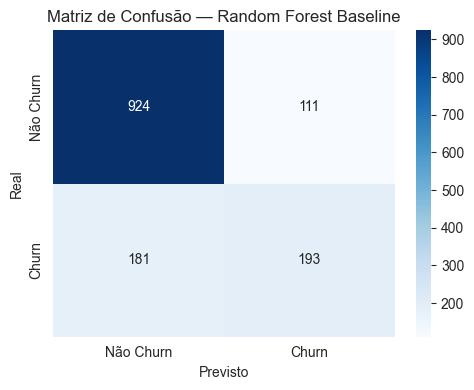

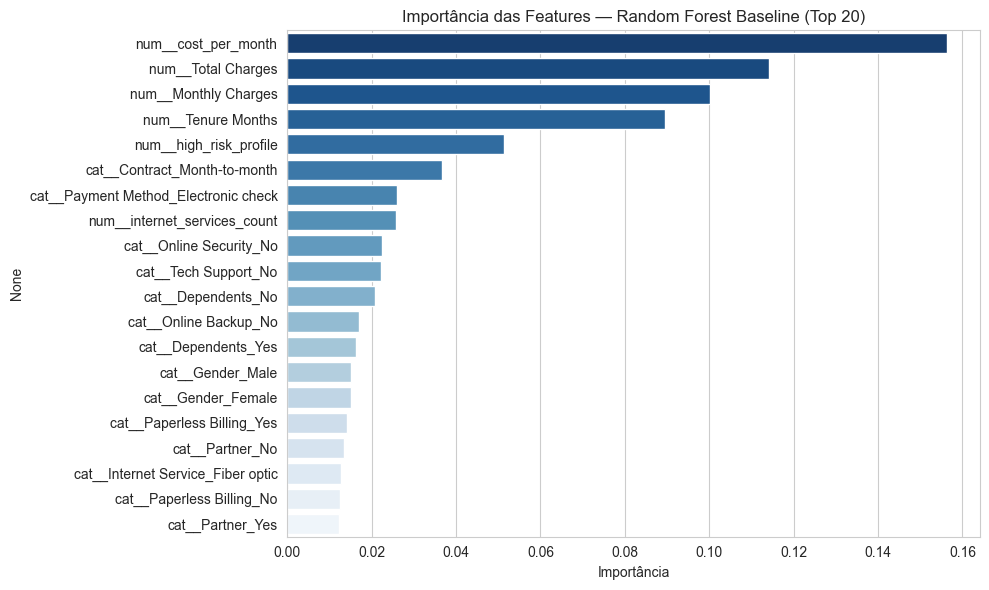

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ── Modelo baseline: Random Forest dentro de Pipeline ────────────────────────
pipe_rf_baseline = SKPipeline([
    ('preprocessor', preprocessor_tree),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

pipe_rf_baseline.fit(X_train_raw, y_train)

y_pred  = pipe_rf_baseline.predict(X_test_raw)
y_proba = pipe_rf_baseline.predict_proba(X_test_raw)[:, 1]

print("=== Relatório de Classificação — Random Forest Baseline ===")
print(classification_report(y_test, y_pred, target_names=['Não Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ── Matriz de Confusão ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'], ax=ax)
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Random Forest Baseline')
plt.tight_layout()
plt.show()

# ── Feature Importance (nomes reais após encoding) ────────────────────────────
rf_clf    = pipe_rf_baseline.named_steps['classifier']
prep      = pipe_rf_baseline.named_steps['preprocessor']
feat_names = prep.get_feature_names_out()

importancias = pd.Series(rf_clf.feature_importances_, index=feat_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=importancias.head(20).values, y=importancias.head(20).index, palette='Blues_r', ax=ax)
ax.set_title('Importância das Features — Random Forest Baseline (Top 20)')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

# Referência para a seção de feature selection
modelo_baseline = pipe_rf_baseline

## 9. Comparação de Algoritmos e Tuning

Função `comparar_modelos()` treina e otimiza múltiplos classificadores:

- **Sem normalização** (tree-based): Random Forest, Gradient Boosting + opcionais XGBoost/LightGBM
- **Com normalização** (Pipeline + StandardScaler): Logistic Regression, KNN, SVM

Cada modelo passa por **RandomizedSearchCV** com validação cruzada estratificada (StratifiedKFold) para encontrar os melhores hiperparâmetros.

O resultado é uma tabela comparativa com Accuracy, Precision, Recall, F1 e ROC-AUC.

In [11]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost nao instalado.')

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM nao instalado.')


# ==========================================================================
# REDE NEURAL — importada de utils/neural_net.py
# Definir as classes num modulo importavel e necessario para que os workers
# do joblib (RandomizedSearchCV n_jobs=-1) consigam desserializar o Pipeline.
# Classes definidas em celulas de notebook existem so no __main__ do processo
# principal e nao sao resolviveis nos subprocessos.
# ==========================================================================
_HAS_TORCH = False
try:
    import torch
    from utils.neural_net import ChurnNet, ChurnNetWrapper
    _HAS_TORCH = True
    print("PyTorch disponivel — ChurnNetWrapper importado de utils.neural_net.")
except ImportError:
    print("PyTorch nao instalado — Neural Network sera omitida dos pipelines.")


# ==========================================================================
# DICIONARIO DE PIPELINES
# ==========================================================================
modelos_pipeline = {

    'Random Forest': (
        SKPipeline([
            ('preprocessor', preprocessor_tree),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   RandomForestClassifier(
                random_state=42, n_jobs=-1, class_weight='balanced')),
        ]),
        {
            'selector__k':                   [20, 25, 30, 35, 40],
            'classifier__n_estimators':      [100, 200, 300, 500],
            'classifier__max_depth':         [None, 5, 10, 15, 20],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf':  [1, 2, 4],
            'classifier__max_features':      ['sqrt', 'log2'],
        },
    ),

    'Gradient Boosting': (
        SKPipeline([
            ('preprocessor', preprocessor_tree),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   GradientBoostingClassifier(random_state=42)),
        ]),
        {
            'selector__k':               [20, 25, 30],
            'classifier__n_estimators':  [100, 200, 300, 500],
            'classifier__max_depth':     [3, 4, 5, 6],
            'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15],
            'classifier__subsample':     [0.7, 0.8, 0.9, 1.0],
        },
    ),

    'Logistic Regression': (
        SKPipeline([
            ('preprocessor', preprocessor_scaled),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   LogisticRegression(
                max_iter=2000, random_state=42, class_weight='balanced')),
        ]),
        {
            'selector__k':          [20, 25, 30],
            'classifier__C':        [0.001, 0.01, 0.1, 1, 10, 100],
            'classifier__penalty':  ['l1', 'l2', 'elasticnet'],
            'classifier__solver':   ['saga'],
            'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        },
    ),

    'KNN': (
        SKPipeline([
            ('preprocessor', preprocessor_scaled),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   KNeighborsClassifier()),
        ]),
        {
            'selector__k':             [20, 25, 30],
            'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'classifier__weights':     ['uniform', 'distance'],
            'classifier__metric':      ['euclidean', 'manhattan'],
        },
    ),

    'SVM': (
        SKPipeline([
            ('preprocessor', preprocessor_scaled),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   SVC(probability=True, random_state=42, class_weight='balanced')),
        ]),
        {
            'selector__k':        [20, 25, 30],
            'classifier__C':      [0.1, 1, 10, 100],
            'classifier__kernel': ['rbf', 'linear', 'poly'],
            'classifier__gamma':  ['scale', 'auto', 0.01, 0.1],
        },
    ),
}

if HAS_XGB:
    modelos_pipeline['XGBoost'] = (
        SKPipeline([
            ('preprocessor', preprocessor_tree),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   XGBClassifier(
                random_state=42, eval_metric='logloss')),
        ]),
        {
            'selector__k':                  [20, 25, 30],
            'classifier__n_estimators':     [100, 200, 300],
            'classifier__max_depth':        [3, 4, 5, 6],
            'classifier__learning_rate':    [0.01, 0.05, 0.1],
            'classifier__subsample':        [0.7, 0.8, 0.9],
            'classifier__colsample_bytree': [0.7, 0.8, 0.9],
            'classifier__scale_pos_weight': [1, 2, 3],
        },
    )

if HAS_LGB:
    modelos_pipeline['LightGBM'] = (
        SKPipeline([
            ('preprocessor', preprocessor_tree),
            ('selector',     SelectKBest(f_classif, k=30)),
            ('classifier',   LGBMClassifier(random_state=42, class_weight='balanced')),
        ]),
        {
            'selector__k':                  [20, 25, 30],
            'classifier__n_estimators':     [100, 200, 300],
            'classifier__num_leaves':       [31, 50, 63],
            'classifier__learning_rate':    [0.01, 0.05, 0.1],
            'classifier__subsample':        [0.7, 0.8, 0.9],
            'classifier__colsample_bytree': [0.7, 0.8, 0.9],
        },
    )

if _HAS_TORCH:
    modelos_pipeline['Neural Network'] = (
        SKPipeline([
            ('preprocessor', preprocessor_scaled),
            ('selector',     SelectKBest(f_classif, k=35)),
            ('classifier',   ChurnNetWrapper(
                lr=1e-4, weight_decay=1e-3, dropout=[0.4, 0.3],
                epochs=500, batch_size=64, patience=50,
                use_focal_loss=True, focal_gamma=3.0, warmup_epochs=10)),
        ]),
        {
            'selector__k':              [25, 30, 35, 40],
            'classifier__lr':           [1e-3, 5e-4, 1e-4],
            'classifier__weight_decay': [1e-4, 1e-3],
            'classifier__dropout':      [[0.3, 0.2], [0.4, 0.3], [0.2, 0.1]],
            'classifier__focal_gamma':  [1.5, 2.0, 3.0],
        },
        1,  # n_jobs=1: evita conflito PyTorch + multiprocessing do joblib
    )

print(f'\nModelos nos pipelines: {list(modelos_pipeline.keys())}')

# ── Treinar, comparar, salvar .pkl e registrar no MLflow ──────────────────
df_comparativo = comparar_modelos(
    X_train_raw, X_test_raw, y_train, y_test,
    modelos=modelos_pipeline,
    n_iter=60, cv=5,
    salvar_modelos=True,
    models_dir='../models',
    experiment_name='churn_mvp',
    tracking_uri='../mlflow_tracking',
)

PyTorch disponivel — ChurnNetWrapper importado de utils.neural_net.

Modelos nos pipelines: ['Random Forest', 'Gradient Boosting', 'Logistic Regression', 'KNN', 'SVM', 'XGBoost', 'LightGBM', 'Neural Network']

>>> Random Forest...


2026/03/19 23:49:25 INFO mlflow.tracking.fluent: Experiment with name 'churn_mvp' does not exist. Creating a new experiment.
2026/03/19 23:49:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ROC-AUC CV : 0.8608
    ROC-AUC    : 0.8510
    Params     : {'selector__k': 25, 'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 5}

>>> Gradient Boosting...


2026/03/19 23:50:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ROC-AUC CV : 0.8639
    ROC-AUC    : 0.8539
    Params     : {'selector__k': 30, 'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01}

>>> Logistic Regression...


...

2026/03/20 00:05:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


    ROC-AUC CV : 0.8616
    ROC-AUC    : 0.8559
    Params     : {'selector__k': 30, 'classifier__subsample': 0.8, 'classifier__num_leaves': 31, 'classifier__n_estimators': 200, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.8}

>>> Neural Network...


2026/03/20 04:17:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/20 04:17:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


    ROC-AUC CV : 0.8541
    ROC-AUC    : 0.8464
    Params     : {'selector__k': 25, 'classifier__weight_decay': 0.0001, 'classifier__lr': 0.0001, 'classifier__focal_gamma': 2.0, 'classifier__dropout': [0.4, 0.3]}

  COMPARATIVO FINAL — TODOS OS MODELOS


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,LightGBM,0.758000,0.528700,0.812800,0.640700,0.855900
1,XGBoost,0.770800,0.550900,0.738000,0.630900,0.854100
2,Gradient Boosting,0.804100,0.667800,0.521400,0.585600,0.853900
3,Random Forest,0.757300,0.528700,0.788800,0.633000,0.851000
4,Logistic Regression,0.741700,0.508700,0.778100,0.615200,0.850300
5,Neural Network,0.735300,0.500800,0.810200,0.619000,0.846400
6,SVM,0.748000,0.517400,0.756700,0.614500,0.842500
7,KNN,0.792800,0.617800,0.574900,0.595600,0.835800


In [ ]:
"""
Script standalone para treinar e otimizar apenas a Neural Network.

Execução:
    python train_nn.py

Ajuste o GRID abaixo para experimentar combinações diferentes.
"""

import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
)


# ──────────────────────────────────────────────────────────────────────────────
# CONFIG — ajuste aqui
# ──────────────────────────────────────────────────────────────────────────────
DATA_PATH  = '../data/Telco_customer_churn.csv'
N_ITER     = 30        # combinações testadas no RandomizedSearchCV
CV_FOLDS   = 5
RANDOM_STATE = 42

GRID = {
    'selector__k':               [25, 30, 35, 40],
    'classifier__lr':            [1e-3, 5e-4, 1e-4],
    'classifier__weight_decay':  [1e-4, 1e-3],
    'classifier__dropout':       [[0.3, 0.2], [0.4, 0.3], [0.2, 0.1]],
    'classifier__focal_gamma':   [1.5, 2.0, 3.0],
}
# ──────────────────────────────────────────────────────────────────────────────


# ── Carrega e prepara dados ───────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['Count', 'CustomerID', 'Churn Reason'], errors='ignore')

df['high_risk_profile'] = (
    (df['Internet Service'] == 'Fiber optic') &
    (df['Contract'] == 'Month-to-month')
).astype(int)

df['isolated_senior'] = (
    (df['Senior Citizen'] == 'Yes') &
    (df['Partner'] == 'No') &
    (df['Dependents'] == 'No')
).astype(int)

servicos = ['Online Security', 'Online Backup', 'Device Protection',
            'Tech Support', 'Streaming TV', 'Streaming Movies']
df['internet_services_count'] = sum((df[c] == 'Yes').astype(int) for c in servicos)
df['cost_per_month'] = df['Monthly Charges'] / (df['Tenure Months'] + 1)

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

leakage  = ['Churn Score', 'CLTV', 'Churn Label']
geo      = ['City', 'Country', 'Lat Long', 'Latitude', 'Longitude', 'Zip Code']
df = df.drop(columns=[c for c in leakage + geo if c in df.columns])

X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Churn no treino: {y_train.mean():.1%}\n")


# ── Preprocessor ─────────────────────────────────────────────────────────────
num_pipe = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = SKPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
], remainder='drop')


# ── Pipeline ──────────────────────────────────────────────────────────────────
pipeline = SKPipeline([
    ('preprocessor', preprocessor),
    ('selector',     SelectKBest(f_classif, k=30)),
    ('classifier',   ChurnNetWrapper(
        epochs=500, batch_size=64, patience=50,
        use_focal_loss=True, focal_gamma=2.0, warmup_epochs=10,
    )),
])


# ── Scorer direto (bypassa verificação is_regressor do sklearn 1.8) ───────────
def roc_auc_scorer(estimator, X, y):
    return roc_auc_score(y, estimator.predict_proba(X)[:, 1])


# ── RandomizedSearchCV ────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    pipeline, GRID,
    n_iter=N_ITER,
    scoring=roc_auc_scorer,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,           # n_jobs=1 para evitar conflito com multiprocessing do PyTorch
    verbose=2,
    error_score='raise',
)

print("Iniciando busca de hiperparâmetros...\n")
search.fit(X_train, y_train)

print(f"\nMelhor ROC-AUC (CV): {search.best_score_:.4f}")
print(f"Melhores params:     {search.best_params_}\n")


# ── Avaliação no teste ────────────────────────────────────────────────────────
best = search.best_estimator_
y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print("=" * 50)
print("  RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 50)
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}   (baseline: 0.8421)")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"  F1       : {f1_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Nao Churn', 'Churn']))


# ── Curva de aprendizado do melhor modelo ─────────────────────────────────────
wrapper = best.named_steps['classifier']
if hasattr(wrapper, 'history_') and wrapper.history_:
    plt.figure(figsize=(10, 4))
    plt.plot(wrapper.history_, color='steelblue')
    plt.xlabel('Epoca')
    plt.ylabel('ROC-AUC (validacao interna)')
    plt.title('Curva de aprendizado — melhor Neural Network')
    plt.tight_layout()
    plt.show()


Treino: (5634, 24) | Teste: (1409, 24)
Churn no treino: 26.5%

Iniciando busca de hiperparâmetros...

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END classifier__dropout=[0.2, 0.1], classifier__focal_gamma=3.0, classifier__lr=0.0005, classifier__weight_decay=0.0001, selector__k=30; total time=  51.9s
[CV] END classifier__dropout=[0.2, 0.1], classifier__focal_gamma=3.0, classifier__lr=0.0005, classifier__weight_decay=0.0001, selector__k=30; total time=  42.3s
[CV] END classifier__dropout=[0.2, 0.1], classifier__focal_gamma=3.0, classifier__lr=0.0005, classifier__weight_decay=0.0001, selector__k=30; total time=  41.6s
[CV] END classifier__dropout=[0.2, 0.1], classifier__focal_gamma=3.0, classifier__lr=0.0005, classifier__weight_decay=0.0001, selector__k=30; total time=  41.2s
[CV] END classifier__dropout=[0.2, 0.1], classifier__focal_gamma=3.0, classifier__lr=0.0005, classifier__weight_decay=0.0001, selector__k=30; total time=  23.4s
[CV] END classifier__dropout=[0

KeyboardInterrupt: 